# Model evaluation and explainability

Loads saved artifacts from `03_lstm_training.ipynb` and evaluates on the held-out test split.


## Section 1 — Setup and imports


In [13]:
import sys
from pathlib import Path

def project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "config.py").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Run from the GUIDAPLATE repo (config.py not found).")

ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "app") not in sys.path:
    sys.path.insert(0, str(ROOT / "app"))

import config
import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    roc_auc_score,
)

import joblib
import tensorflow as tf
from tensorflow import keras

# Load new saved splits
rf_split = np.load(config.MODELS_DIR / "rf_test_split.npz", allow_pickle=True)
lstm_split = np.load(config.MODELS_DIR / "lstm_test_split.npz", allow_pickle=True)

X_test_flat = rf_split["X_test_scaled"]
y_test_real = rf_split["y_test"].astype(int)
idx_test_real = rf_split["idx_test"]
feature_names = rf_split["feature_names"].tolist()

X_test_seq = lstm_split["X_test_seq"]
y_test = lstm_split["y_test"].astype(int)  # keep name used below for LSTM sections
idx_test_syn = lstm_split["idx_test"]

# Load scalers + models
rf_scaler = joblib.load(config.MODELS_DIR / "rf_scaler.pkl")
lstm_scaler = joblib.load(config.MODELS_DIR / "lstm_scaler.pkl")

model = keras.models.load_model(config.LSTM_MODEL_PATH)

# Best tabular model is whichever exists from training
best_tabular_path = None
for cand in [config.XGBOOST_MODEL_PATH, config.RANDOM_FOREST_PATH, config.MODELS_DIR / "log_reg.pkl"]:
    if Path(cand).exists():
        best_tabular_path = cand
        break

best_tabular = joblib.load(best_tabular_path) if best_tabular_path else None

print("Real test (tabular):", X_test_flat.shape, "y:", y_test_real.shape)
print("Synthetic test (seq):", X_test_seq.shape, "y:", y_test.shape)
print("Best tabular model:", best_tabular_path)
print("Feature names:", feature_names)


Real test (tabular): (354, 11) y: (354,)
Synthetic test (seq): (200, 30, 5) y: (200,)
Best tabular model: /Users/jade/GUIDAPLATE/models/xgboost.pkl
Feature names: ['ckd_stage_encoded', 'RIDAGEYR', 'RIAGENDR', 'DR1TPOTA', 'DR1TPHOS', 'DR1TPROT', 'DR1TSODI', 'DR2TPOTA', 'DR2TPHOS', 'DR2TPROT', 'DR2TSODI']


## Section 2 — Detailed LSTM evaluation


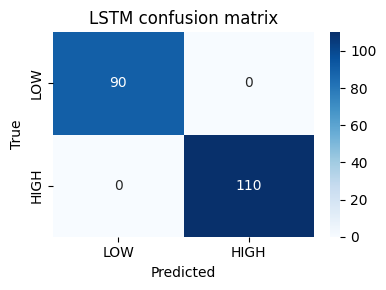

              precision    recall  f1-score   support

         LOW       1.00      1.00      1.00        90
        HIGH       1.00      1.00      1.00       110

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



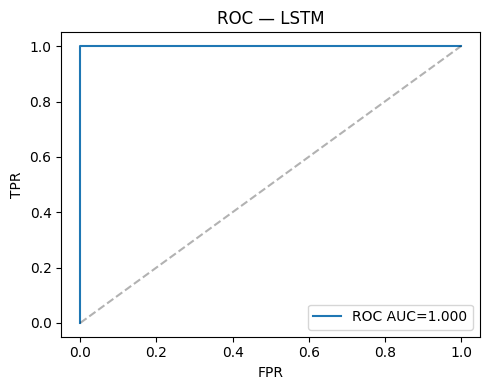

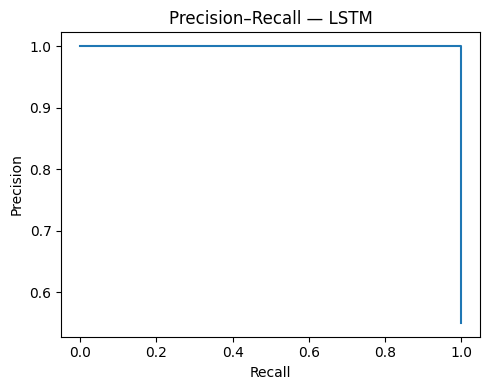

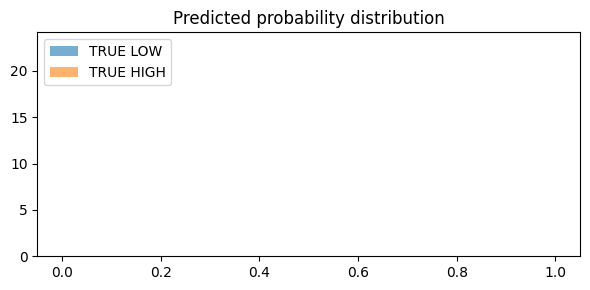

In [14]:

proba = model.predict(X_test_seq, verbose=0).reshape(-1)
pred = (proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred, labels=[0, 1])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["LOW", "HIGH"], yticklabels=["LOW", "HIGH"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("LSTM confusion matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred, target_names=["LOW", "HIGH"]))

fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"ROC AUC={auc(fpr, tpr):.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.3)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC — LSTM")
plt.legend()
plt.tight_layout()
plt.show()

prec, rec, _ = precision_recall_curve(y_test, proba)
plt.figure(figsize=(5, 4))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — LSTM")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.hist(proba[y_test == 0], bins=30, alpha=0.6, label="TRUE LOW")
plt.hist(proba[y_test == 1], bins=30, alpha=0.6, label="TRUE HIGH")
plt.title("Predicted probability distribution")
plt.legend()
plt.tight_layout()
plt.show()


## Section 3 — Error analysis


Misclassified count: 0 / 200
Errors by CKD stage (row-level):
Series([], )


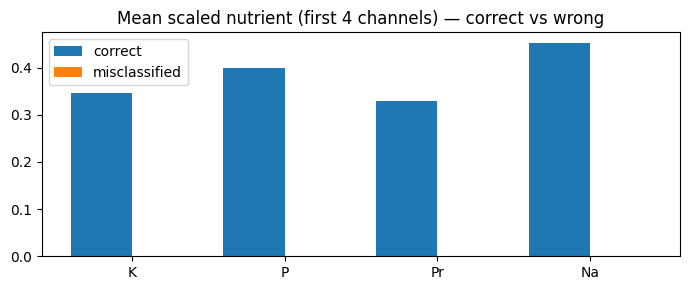

In [15]:

wrong = np.where(pred != y_test)[0]
print("Misclassified count:", len(wrong), "/", len(y_test))

lab = pd.read_csv(config.SYNTHETIC_LABELS_CSV)
stages = lab.iloc[idx_test_syn.astype(int)]["ckd_stage"].to_numpy()
err_stage = pd.Series(stages[wrong]).value_counts()
print("Errors by CKD stage (row-level):")
print(err_stage.to_string())

# Mean nutrient profile on errors vs correct
feat_names = ["K", "P", "Pr", "Na"]
mean_err = X_test_seq[wrong, :, :4].mean(axis=(0, 1)) if len(wrong) else np.zeros(4)
ok = np.where(pred == y_test)[0]
mean_ok = X_test_seq[ok, :, :4].mean(axis=(0, 1)) if len(ok) else np.zeros(4)

plt.figure(figsize=(7, 3))
plt.bar(np.arange(4) - 0.2, mean_ok, width=0.4, label="correct")
plt.bar(np.arange(4) + 0.2, mean_err, width=0.4, label="misclassified")
plt.xticks(np.arange(4), feat_names)
plt.title("Mean scaled nutrient (first 4 channels) — correct vs wrong")
plt.legend()
plt.tight_layout()
plt.show()


## Section 4 — SHAP explainability (LSTM)


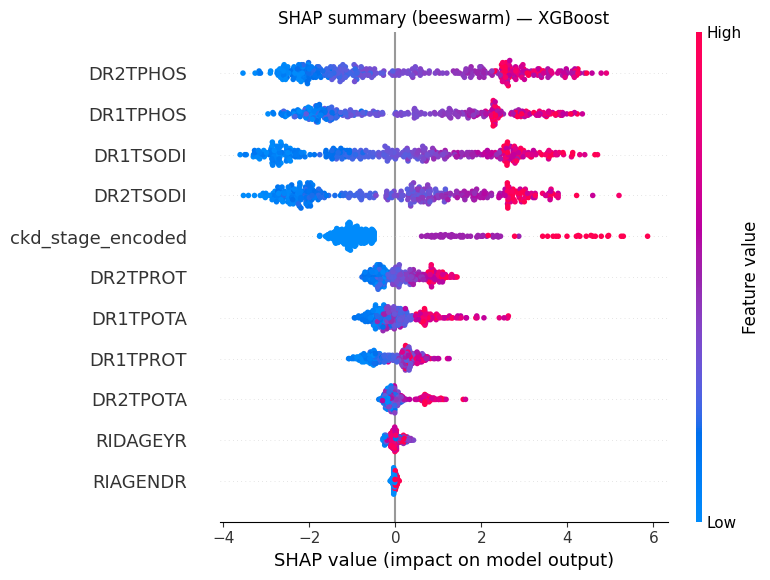

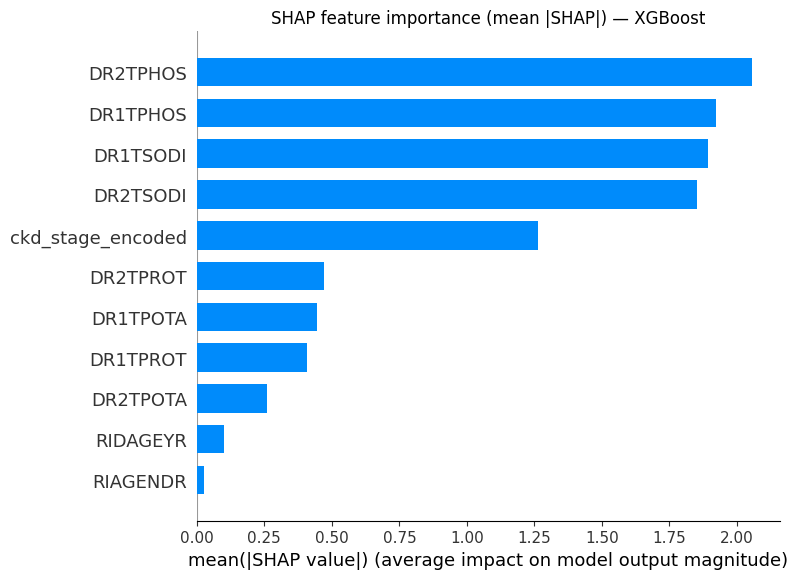

Feature importance ranking (mean |SHAP|):
DR2TPHOS             2.056583
DR1TPHOS             1.923461
DR1TSODI             1.891984
DR2TSODI             1.850699
ckd_stage_encoded    1.264454
DR2TPROT             0.471452
DR1TPOTA             0.446436
DR1TPROT             0.408104
DR2TPOTA             0.260546
RIDAGEYR             0.101830
RIAGENDR             0.028053

Top 5 most important features:
DR2TPHOS             2.056583
DR1TPHOS             1.923461
DR1TSODI             1.891984
DR2TSODI             1.850699
ckd_stage_encoded    1.264454


In [16]:
# SHAP explainability for the *tabular* model (XGBoost) using TreeExplainer.
# This avoids TensorFlow DeepExplainer incompatibilities.

try:
    import shap  # type: ignore
except ModuleNotFoundError:
    shap = None

if shap is None:
    print("SHAP not installed; skipping SHAP section.")
    print("Install with: python3 -m pip install shap")
else:
    # Load XGBoost model (preferred). If not present, fall back to whatever tabular model was saved.
    xgb_path = config.XGBOOST_MODEL_PATH
    if not Path(xgb_path).exists():
        raise FileNotFoundError(
            f"Expected XGBoost model at {xgb_path}. Run 03_lstm_training.ipynb and ensure XGBoost is saved."
        )

    xgb_model = joblib.load(xgb_path)

    # Feature names in the expected training order
    feature_names = [
        "ckd_stage_encoded",
        "RIDAGEYR",
        "RIAGENDR",
        "DR1TPOTA",
        "DR1TPHOS",
        "DR1TPROT",
        "DR1TSODI",
        "DR2TPOTA",
        "DR2TPHOS",
        "DR2TPROT",
        "DR2TSODI",
    ]

    if X_test_flat.shape[1] != len(feature_names):
        raise ValueError(
            f"X_test_flat has {X_test_flat.shape[1]} features but feature_names has {len(feature_names)}."
        )

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_flat)

    # For some SHAP versions/models, shap_values may be a list (e.g. per-class). Use the positive class if so.
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]

    # Summary (beeswarm)
    plt.figure(figsize=(10, 5))
    shap.summary_plot(
        shap_values,
        X_test_flat,
        feature_names=feature_names,
        show=False,
    )
    plt.title("SHAP summary (beeswarm) — XGBoost")
    plt.tight_layout()
    plt.show()

    # Bar plot (mean absolute SHAP)
    plt.figure(figsize=(10, 5))
    shap.summary_plot(
        shap_values,
        X_test_flat,
        feature_names=feature_names,
        plot_type="bar",
        show=False,
    )
    plt.title("SHAP feature importance (mean |SHAP|) — XGBoost")
    plt.tight_layout()
    plt.show()

    # Feature importance ranking
    mean_abs = np.abs(shap_values).mean(axis=0)
    imp = pd.Series(mean_abs, index=feature_names).sort_values(ascending=False)
    print("Feature importance ranking (mean |SHAP|):")
    print(imp.to_string())

    print("\nTop 5 most important features:")
    print(imp.head(5).to_string())


## Section 5 — Clinical validation vs rules


In [17]:

THR = config.DIETARY_RISK_THRESHOLDS
STAGE_FROM_CODE = {int(v): k for k, v in config.CKD_STAGE_ENCODING.items()}


def baseline_predict(Xseq: np.ndarray) -> np.ndarray:
    preds = []
    for j in range(len(Xseq)):
        s = Xseq[j]
        st = STAGE_FROM_CODE.get(int(s[0, 4]), "G2")
        t = THR[st]
        ex = (
            (s[:, 0] > t["potassium"])
            | (s[:, 1] > t["phosphorus"])
            | (s[:, 2] > t["protein"])
            | (s[:, 3] > t["sodium"])
        )
        preds.append(int(ex.mean() > 0.5))
    return np.array(preds, dtype=int)


y_rule = baseline_predict(X_test_seq)
agree = (y_rule == pred).mean()
print("Agreement rate (rule vs LSTM hard label):", float(agree))

# Where LSTM flags HIGH but rule LOW
mismatch = np.where((pred == 1) & (y_rule == 0))[0]
print("LSTM HIGH & rule LOW count:", len(mismatch))


Agreement rate (rule vs LSTM hard label): 0.45
LSTM HIGH & rule LOW count: 110


## Section 6 — Final model report

- **Best model**: compare AUC/F1 from the training notebook table.
- **Clinical relevance**: dietary thresholds are rough guidelines; NHANES recalls are noisy.
- **Limitations**: synthetic days are i.i.d. normal draws; real temporal autocorrelation differs.
- **Deployment**: validate prospectively, monitor drift, and keep human-in-the-loop.
